# 📊 Exploratory Data Analysis (EDA)
## FakeGuard — Fake News Detection System

In this section, we analyze the dataset to understand:
- Distribution of fake vs real news
- Text length patterns
- Basic structure of the dataset

This helps us identify patterns before applying NLP models.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import nltk
import re
import warnings
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "svg"

warnings.filterwarnings('ignore')

BG = "#0D1117"         
CARD = "#161B22"        
GRID = "#30363D"

FAKE_RED = "#FF4B4B"
REAL_GREEN = "#00CC88"

BLUE = "#58A6FF"
YELLOW = "#F2CC60"

TEXT = "#E6EDF3"
MUTED = "#8B949E"

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

## 📂 Dataset Overview

We are using the Kaggle dataset:
- Fake.csv → Label = 0 (Fake News)
- True.csv → Label = 1 (Real News)

We combine both datasets and shuffle them for training consistency.

In [28]:
# load dataset
df = pd.read_csv('../data/raw/Dataset.csv')

# drop nulls and unusable rows
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']
df = df.reset_index(drop=True)

# combine title + text for richer signal
df['text'] = df['title'].fillna('') + ' ' + df['text']

# shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df[['text', 'label']].head()

,text,label
0,Comment on Corporate Democratic Party Think Ta...,1
1,Wikileaks Email: Clinton Operative Thinks “Bla...,1
2,They Asked Hillary If Trump Is Qualified To B...,1
3,'Strong' Franco-British defense relationship w...,0
4,Aggressive cuts to Obama-era green rules to st...,0


## 📊 Class Distribution

We first check whether the dataset is balanced between fake and real news.
This is important because imbalance can affect model performance.

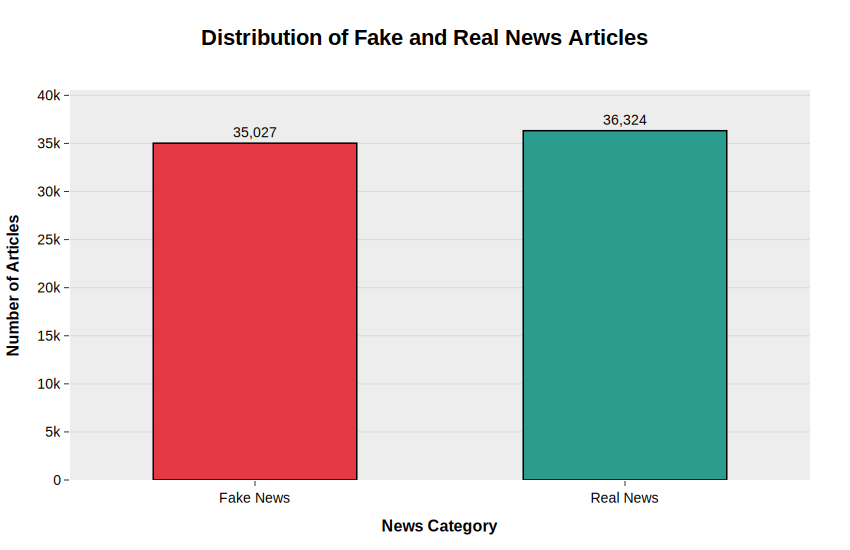

In [29]:
label_counts = df['label'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=['Fake News', 'Real News'],
        y=label_counts.values,
        text=[f"{v:,}" for v in label_counts.values],
        textposition='outside',
        marker=dict(
            color=['#E63946', '#2A9D8F'],
            line=dict(color='black', width=1.5)
        ),
        width=0.55,
        hoverinfo='skip'
    )
)

fig.update_layout(
    title=dict(
        text="<b>Distribution of Fake and Real News Articles</b>",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        title="<b>News Category</b>",
        title_font=dict(size=16),
        tickfont=dict(size=14),
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        title="<b>Number of Articles</b>",
        title_font=dict(size=16),
        tickfont=dict(size=14),
        showgrid=True,
        gridcolor='rgba(0,0,0,0.08)',
        zeroline=False
    ),
    template='ggplot2',
    font=dict(
        family="Arial",
        size=14,
        color="black"
    ),
    width=850,
    height=550,
    margin=dict(
        l=70,
        r=40,
        t=90,
        b=70
    ),

    showlegend=False
)

fig.show()

## 📏 Article Length Analysis

We analyze the number of words in each article to see if fake and real news differ in writing style or structure.

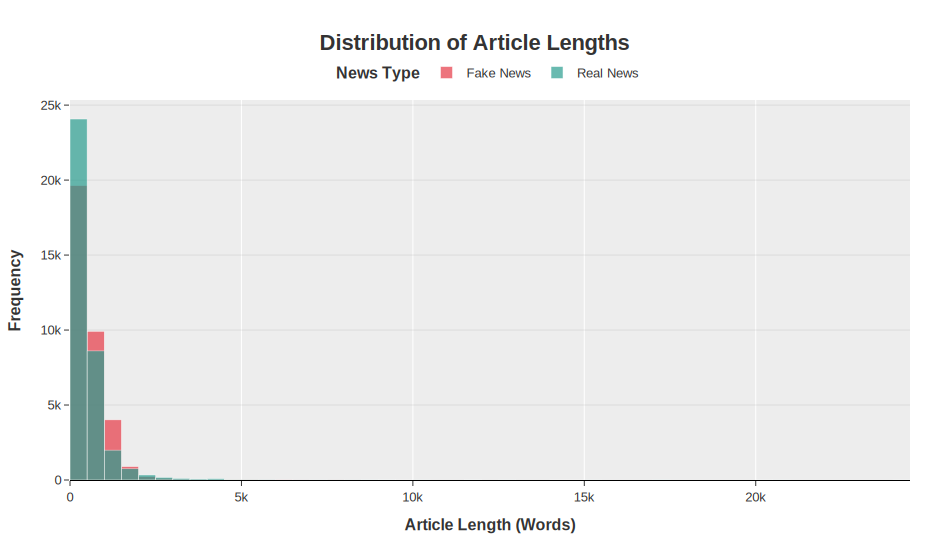

In [30]:
# Create length feature
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

fake_len = df[df['label'] == 0]['text_length']
real_len = df[df['label'] == 1]['text_length']

fig = go.Figure()

# Fake News
fig.add_trace(go.Histogram(
    x=fake_len,
    name='Fake News',
    nbinsx=60,
    opacity=0.70,
    marker=dict(
        color='#E63946',
        line=dict(color='white', width=0.5)
    )
))

# Real News
fig.add_trace(go.Histogram(
    x=real_len,
    name='Real News',
    nbinsx=60,
    opacity=0.70,
    marker=dict(
        color='#2A9D8F',
        line=dict(color='white', width=0.5)
    )
))

fig.update_layout(
    title=dict(
        text="<b>Distribution of Article Lengths</b><br>",
        x=0.5,
        font=dict(size=22)
    ),

    xaxis=dict(
        title="<b>Article Length (Words)</b>",
        title_font=dict(size=16),
        tickfont=dict(size=13),
        showline=True,
        linewidth=1,
        linecolor='black'
    ),

    yaxis=dict(
        title="<b>Frequency</b>",
        title_font=dict(size=16),
        tickfont=dict(size=13),
        showgrid=True,
        gridcolor='rgba(0,0,0,0.08)',
        zeroline=False
    ),

    barmode='overlay',

    template='ggplot2',

    font=dict(
        family='Arial',
        size=14
    ),

    legend=dict(
        title="<b>News Type</b>",
        orientation='h',
        yanchor='bottom',
        y=1.03,
        xanchor='center',
        x=0.5,
        font=dict(size=13)
    ),

    width=950,
    height=550,

    margin=dict(
        l=70,
        r=40,
        t=100,
        b=70
    )
)

fig.show()

## 🧹 Data Preparation

We retain only:
- `text` → input feature
- `label` → target variable

This ensures consistency for NLP preprocessing and model training.

In [31]:
df = df[['text', 'label']].dropna()
df.to_csv('../data/processed/cleaned_data.csv', index=False)

# 🧹  Text Preprocessing Pipeline

In this phase, we clean raw text data to prepare it for machine learning models.

We convert unstructured news articles into structured numerical-friendly text using NLP techniques like tokenization, stopword removal, and lemmatization.

In [32]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove non-letters
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize 
    tokens = text.split()

    # remove stopwords + short words + lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(tokens)

In [33]:
df['cleaned_text'] = df['text'].apply(clean_text)
df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,Comment on Corporate Democratic Party Think Ta...,comment corporate democratic party think tank ...
1,Wikileaks Email: Clinton Operative Thinks “Bla...,wikileaks email clinton operative think black ...
2,They Asked Hillary If Trump Is Qualified To B...,asked hillary trump qualified president answer...
3,'Strong' Franco-British defense relationship w...,strong francobritish defense relationship wont...
4,Aggressive cuts to Obama-era green rules to st...,aggressive cut obamaera green rule start soon ...


In [34]:
PLOT_TEMPLATE = dict(
    paper_bgcolor=BG,
    plot_bgcolor=CARD,
    font=dict(
        color=TEXT,
        size=13
    ),
    title=dict(
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        gridcolor=GRID,
        zerolinecolor=GRID
    ),
    yaxis=dict(
        gridcolor=GRID,
        zerolinecolor=GRID
    )
)

# 🤖 TF-IDF Vectorization & Model Training

In this phase, the cleaned text data is converted into numerical representations using TF-IDF (Term Frequency–Inverse Document Frequency).

The transformed features are then used to train and evaluate multiple machine learning models for fake news classification.

### Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 57080
Testing samples  : 14271


## 📌 Data Splitting

The dataset is divided into training and testing sets using an 80:20 ratio.

- Training Set → Used to train the models
- Testing Set → Used to evaluate performance on unseen data

Stratified sampling is used to preserve the class distribution.

## 🔤 TF-IDF Feature Extraction

TF-IDF converts textual data into numerical vectors by assigning weights to words based on their importance.

Configuration:
- Maximum Features: 10,000
- N-grams: Unigrams and Bigrams
- Minimum Document Frequency: 2
- Sublinear TF Scaling Enabled

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Matrix Shape:", X_train_tfidf.shape)
print("Testing Matrix Shape :", X_test_tfidf.shape)

Training Matrix Shape: (57080, 10000)
Testing Matrix Shape : (14271, 10000)


## 🏋️ Model Training

Three machine learning algorithms are trained and compared:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Random Forest Classifier

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42
    ),

    'Naive Bayes': MultinomialNB(
        alpha=0.1
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

In [38]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    trained_models[name] = model

    print(f"✅ {name} trained successfully.\n")

Training Logistic Regression...
✅ Logistic Regression trained successfully.

Training Naive Bayes...
✅ Naive Bayes trained successfully.

Training Random Forest...
✅ Random Forest trained successfully.



# 📈  Model Evaluation

After training the machine learning models, it is essential to evaluate their ability to classify fake and real news accurately.

To obtain a comprehensive understanding of model performance, multiple evaluation metrics are considered instead of relying solely on accuracy.

The following metrics are used:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

These metrics provide insights into different aspects of model behaviour and help identify the most suitable model for deployment.

## 📊 Performance Metrics

Each trained model is evaluated on the unseen test dataset.

The objective is to compare the strengths and weaknesses of the models under identical testing conditions.

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

results = {}

y_pred_store = {}
y_prob_store = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test_tfidf)

    y_prob = model.predict_proba(X_test_tfidf)[:, 1]

    y_pred_store[name] = y_pred
    y_prob_store[name] = y_prob

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

## 📋 Model Comparison Summary

The following table presents the evaluation metrics for all trained models.

Higher values generally indicate better performance.

In [40]:
results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("F1-Score", ascending=False)
)

results_df = results_df.round(4)

results_df.style\
    .background_gradient(cmap="Greens")\
    .format("{:.4f}")\
    .set_caption("Model Performance Comparison")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9631,0.9596,0.9683,0.9640,0.9927
Random Forest,0.9592,0.9512,0.9696,0.9603,0.9930
Naive Bayes,0.8638,0.8453,0.8965,0.8701,0.9376


## 📌 Accuracy Comparison

This visualization compares the classification accuracy of the three machine learning models.

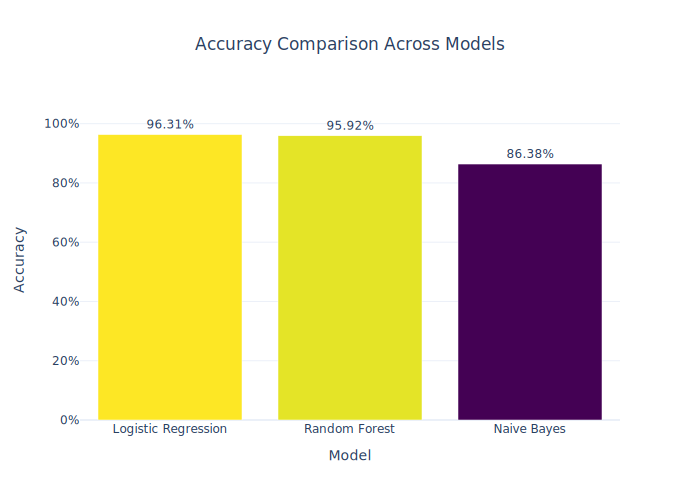

In [41]:
acc_df = (
    results_df.reset_index()
    .rename(columns={"index": "Model"})
)

fig = px.bar(
    acc_df,
    x="Model",
    y="Accuracy",
    text="Accuracy",
    color="Accuracy",
    color_continuous_scale="Viridis",
    title="Accuracy Comparison Across Models"
)

fig.update_traces(
    texttemplate="%{text:.2%}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Model",
    yaxis_title="Accuracy",
    yaxis_tickformat=".0%",
    coloraxis_showscale=False
)

fig.show()

### Interpretation

The model with the highest accuracy demonstrates the greatest proportion of correctly classified news articles on the test dataset.

However, accuracy alone is insufficient and should be interpreted alongside precision, recall, and ROC-AUC.

## 🔲 Confusion Matrix Analysis

A confusion matrix provides a detailed summary of classification outcomes by comparing actual labels with predicted labels.

Unlike accuracy alone, it highlights the types of errors made by each model and helps assess their reliability.

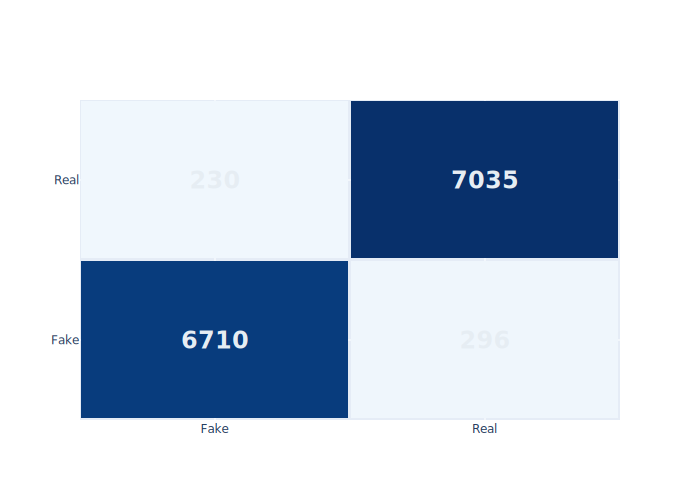

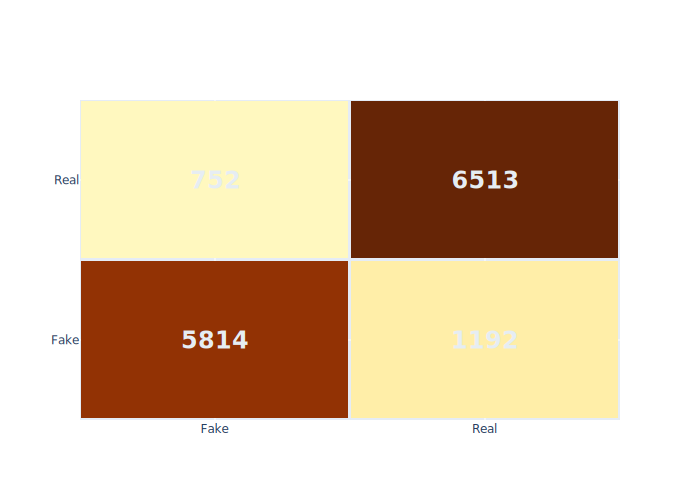

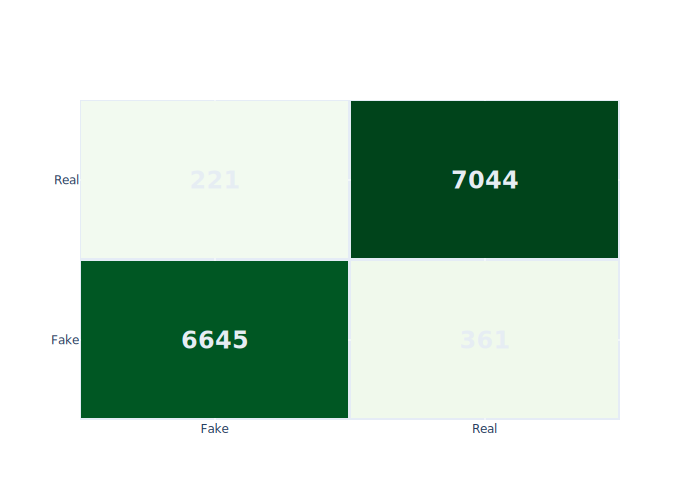

In [51]:
plotly_colors = {
    "Logistic Regression": "Blues",
    "Naive Bayes": "YlOrBr",
    "Random Forest": "Greens"
}

for model_name in y_pred_store.keys():

    cm = confusion_matrix(y_test, y_pred_store[model_name])

    fig = go.Figure(
                data=go.Heatmap(
                z=cm,
                x=["Fake", "Real"],
                y=["Fake", "Real"],

                colorscale=plotly_colors[model_name],
                zmin=0,
                zmax=cm.max(),

                showscale=False,
    
                text=cm.astype(str),
                texttemplate="<b>%{text}</b>",
                textfont=dict(
                    size=24,
                    color="#E6EDF3"
                ),

                xgap=3,
                ygap=3
                )
            )

    fig.show()

## 📈 ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Area Under the Curve (AUC) measures the model's ability to distinguish between fake and real news articles. Higher AUC values indicate stronger discriminative performance.

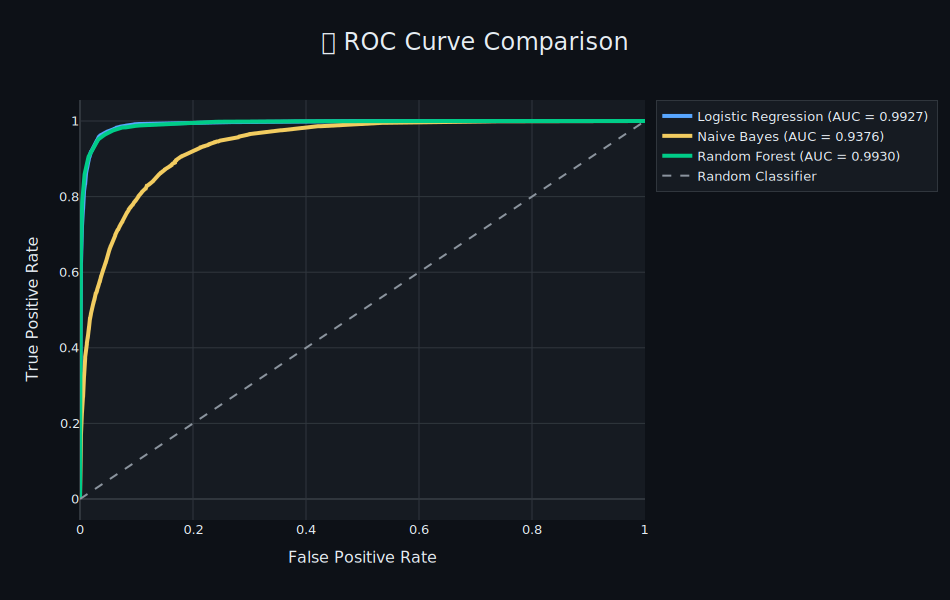

In [52]:
fig = go.Figure()

model_colors = {
    "Logistic Regression": "#58A6FF",
    "Naive Bayes": "#F2CC60",
    "Random Forest": "#00CC88"
}

for model_name, y_prob in y_prob_store.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = results[model_name]["ROC-AUC"]

    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            mode="lines",
            name=f"{model_name} (AUC = {auc_score:.4f})",
            line=dict(
                width=4,
                color=model_colors[model_name]
            )
        )
    )

fig.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Random Classifier",
        line=dict(
            color="#8B949E",
            dash="dash",
            width=2
        )
    )
)

fig.update_layout(
    title=dict(
        text="📈 ROC Curve Comparison",
        x=0.5,
        font=dict(size=24, color=TEXT)
    ),

    paper_bgcolor=BG,
    plot_bgcolor=CARD,

    width=950,
    height=600,

    font=dict(
        color=TEXT,
        size=13
    ),

    xaxis=dict(
        title="False Positive Rate",
        gridcolor=GRID,
        zerolinecolor=GRID
    ),

    yaxis=dict(
        title="True Positive Rate",
        gridcolor=GRID,
        zerolinecolor=GRID
    ),

    legend=dict(
        bgcolor=CARD,
        bordercolor=GRID,
        borderwidth=1
    )
)

fig.show()

### Interpretation

All three models achieved excellent discriminative performance, as indicated by their ROC curves approaching the upper-left corner of the graph.

The Random Forest classifier achieved the highest AUC score, demonstrating the strongest capability to distinguish between fake and real news articles on this dataset.

## 📝 Classification Reports

Classification reports provide class-wise precision, recall, and F1-scores, enabling a more detailed assessment of model performance.

In [53]:
for model_name, y_pred in y_pred_store.items():

    print("=" * 80)
    print(model_name.upper())
    print("=" * 80)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Fake", "Real"],
            digits=4
        )
    )

    print("\n")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

        Fake     0.9669    0.9578    0.9623      7006
        Real     0.9596    0.9683    0.9640      7265

    accuracy                         0.9631     14271
   macro avg     0.9632    0.9630    0.9631     14271
weighted avg     0.9632    0.9631    0.9631     14271



NAIVE BAYES
              precision    recall  f1-score   support

        Fake     0.8855    0.8299    0.8568      7006
        Real     0.8453    0.8965    0.8701      7265

    accuracy                         0.8638     14271
   macro avg     0.8654    0.8632    0.8635     14271
weighted avg     0.8650    0.8638    0.8636     14271



RANDOM FOREST
              precision    recall  f1-score   support

        Fake     0.9678    0.9485    0.9580      7006
        Real     0.9512    0.9696    0.9603      7265

    accuracy                         0.9592     14271
   macro avg     0.9595    0.9590    0.9592     14271
weighted avg     0.9594 

## 🔍 Misclassification Analysis

Although the models achieved very high performance, examining misclassified samples provides insight into their limitations and highlights potentially ambiguous news articles.

In [54]:
best_model = "Logistic Regression"

misclassified = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": y_test.reset_index(drop=True),
    "predicted": y_pred_store[best_model]
})

errors = misclassified[
    misclassified["actual"] != misclassified["predicted"]
]

print(f"Total Misclassified Samples: {len(errors)}")

Total Misclassified Samples: 526


In [55]:
for idx, row in errors.head(3).iterrows():

    print("=" * 100)

    print(
        f"Actual : {'REAL' if row['actual']==1 else 'FAKE'}"
    )

    print(
        f"Predicted : {'REAL' if row['predicted']==1 else 'FAKE'}"
    )

    print("\nArticle Preview:\n")

    print(row["text"][:500])

    print("\n")

Actual : FAKE
Predicted : REAL

Article Preview:

amazon july day action net neutrality big communist anniversary breitbart amazon mobilizing july collective day action tech corporation social justice warrior unite rebelling fcc effort overturn net neutrality fall anniversary lenin call deploy russian communist start civil war around world worker world unite corporate interest amazon ceo jeff bezos mobilized big tech corporate support mozilla reddit kickstarter etsy vimeo fill street ally american civil liberty union aclu electronic frontier fo


Actual : FAKE
Predicted : REAL

Article Preview:

highway horror mexican cartel kidnap murder beer delivery men san fernando tamaulipas lack security condition along highway drug cartel operate border state present image impunity two beer delivery men robbed gunpoint kidnapped executed making regular delivery day kidnapping authority found remains two men area near state limit tamaulipas nuevo leon last week large group friend loved one gather

## 🏆 Model Evaluation Summary

Three machine learning algorithms were evaluated using TF-IDF representations of news articles.

Among them, the Random Forest classifier achieved the strongest overall performance across all evaluation metrics, including Accuracy, F1-Score, and ROC-AUC.

Logistic Regression demonstrated highly competitive results while offering advantages in interpretability and computational efficiency, making it a practical choice for deployment.

Naive Bayes provided the fastest training process but yielded comparatively lower predictive performance.

Based on the experimental findings, Random Forest was identified as the best-performing model for this dataset and experimental setup.

#  Inference & Testing

After training and evaluating the models, an inference pipeline was developed to enable predictions on unseen news articles.

This section loads the saved artifacts and validates the complete prediction workflow by testing the models on manually written news samples.

In [56]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

joblib.dump(
    trained_models["Logistic Regression"],
    "../models/logistic_regression.pkl"
)

joblib.dump(
    trained_models["Naive Bayes"],
    "../models/naive_bayes.pkl"
)

joblib.dump(
    trained_models["Random Forest"],
    "../models/random_forest.pkl"
)

print("✅ All artifacts saved successfully!")

✅ All artifacts saved successfully!


## Building the Prediction Pipeline

A reusable prediction class was implemented to encapsulate preprocessing, vectorization, model loading, and inference into a single interface.

In [57]:
class FakeNewsPredictor:

    MODEL_PATHS = {
        "Logistic Regression": "../models/logistic_regression.pkl",
        "Naive Bayes": "../models/naive_bayes.pkl",
        "Random Forest": "../models/random_forest.pkl"
    }

    VECTORIZER_PATH = "../models/tfidf_vectorizer.pkl"

    def __init__(self):

        self.vectorizer = joblib.load(self.VECTORIZER_PATH)

        self.models = {
            name: joblib.load(path)
            for name, path in self.MODEL_PATHS.items()
        }

    def predict(self, text, model_name):

        cleaned = clean_text(text)

        vec = self.vectorizer.transform([cleaned])

        model = self.models[model_name]

        prediction = model.predict(vec)[0]

        probabilities = model.predict_proba(vec)[0]

        return {
            "label": "FAKE" if prediction == 0 else "REAL",

            "confidence": float(np.max(probabilities)),

            "probabilities": {
                "FAKE": float(probabilities[0]),
                "REAL": float(probabilities[1])
            }
        }

In [58]:
predictor = FakeNewsPredictor()

print("✅ Predictor initialized successfully.")

✅ Predictor initialized successfully.


## Testing on Sample News Articles

The prediction pipeline was validated using manually curated examples representing both fake and legitimate news scenarios.

In [59]:
sample_1 = """
WASHINGTON (Reuters) - The Federal Reserve announced on Wednesday that it would maintain its current monetary policy stance while monitoring inflation trends and labor market conditions.
"""
sample_2 = """
BREAKING: Secret government documents reveal that world leaders have confirmed the Earth is flat and have hidden the truth for decades.
"""

In [60]:
samples = [
  sample_1 , sample_2
]

for text in samples:

    result = predictor.predict(
        text,
        "Logistic Regression"
    )

    print("=" * 80)

    print("Input:")
    print(text.strip())

    print("\nPrediction:")
    print(result["label"])

    print(
        f"Confidence: {result['confidence']:.2%}"
    )

    print(
        f"Probabilities: {result['probabilities']}"
    )

    print()

Input:
WASHINGTON (Reuters) - The Federal Reserve announced on Wednesday that it would maintain its current monetary policy stance while monitoring inflation trends and labor market conditions.

Prediction:
FAKE
Confidence: 94.89%
Probabilities: {'FAKE': 0.9488754545334405, 'REAL': 0.051124545466559576}

Input:
BREAKING: Secret government documents reveal that world leaders have confirmed the Earth is flat and have hidden the truth for decades.

Prediction:
REAL
Confidence: 99.18%
Probabilities: {'FAKE': 0.008164022494600687, 'REAL': 0.9918359775053993}



### Limitations

Although the models achieved excellent performance on the benchmark dataset, testing on short manually written statements revealed reduced generalization ability.

This behaviour suggests that the models partially learned stylistic characteristics present in the dataset (e.g., Reuters-style reporting patterns) rather than purely factual distinctions.

Future work could involve training on more diverse datasets containing shorter and more varied news articles to improve real-world robustness.

## Conclusion

In this project, a complete Fake News Detection System named **FakeGuard** was developed using Natural Language Processing (NLP) and traditional Machine Learning techniques.

The workflow began with exploratory analysis of the Fake and Real News dataset, followed by a structured text preprocessing pipeline involving lowercasing, removal of URLs and HTML tags, stopword filtering, and lemmatization. The cleaned textual data was then transformed into numerical representations using the **TF-IDF vectorization** technique.

Three machine learning algorithms were trained and evaluated:

* Logistic Regression
* Multinomial Naive Bayes
* Random Forest Classifier

A comprehensive evaluation was performed using multiple performance metrics, including **Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrices, and Classification Reports**.

Among the evaluated models, **Logistic Regression demonstrated the strongest overall performance**, achieving the highest Accuracy, Precision, and F1-Score while maintaining excellent ROC-AUC values. Although Random Forest exhibited slightly higher Recall and ROC-AUC scores, the differences were marginal. Considering both predictive performance and computational efficiency, Logistic Regression emerged as the most suitable model for deployment. Multinomial Naive Bayes provided the fastest training and inference times but showed comparatively lower performance across evaluation metrics.

The developed inference pipeline successfully integrated preprocessing, vectorization, and prediction into a reusable framework. Furthermore, the project was extended with a Streamlit-based user interface, enabling users to interactively analyze news articles and obtain authenticity predictions in real time.

Overall, this project demonstrates that carefully engineered text preprocessing combined with classical machine learning approaches can serve as an effective and efficient solution for fake news detection tasks.
